# Deadline Predictor V3 - Improved Model

## Improvements over V2:
1. **Feature Engineering** - Added derived features from sprint data
2. **Multiple Models** - Comparing XGBoost, Random Forest, and Gradient Boosting
3. **Outlier Handling** - Removed extreme values that skew predictions
4. **Hyperparameter Tuning** - GridSearchCV for optimal parameters
5. **Same output format** - Compatible with n8n workflow


In [11]:
import os, math, warnings
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_absolute_percentage_error,
    root_mean_squared_error, r2_score
)
import joblib

# Try importing XGBoost
try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print('XGBoost not available, will skip XGBoost model')

warnings.filterwarnings('ignore')


In [12]:
# -------------------------------------------------------
# 1️⃣ Helper functions
# -------------------------------------------------------
def _lower_cols(df):
    df = df.copy()
    df.columns = [c.strip().replace(' ', '_').lower() for c in df.columns]
    return df

def _parse_date(x):
    if pd.isna(x): return np.nan
    try: return pd.to_datetime(x, errors='coerce')
    except: return np.nan

def safe_div(a,b,default=0.0):
    try: return float(a)/float(b) if b and not pd.isna(b) else default
    except: return default

def coalesce(*vals):
    for v in vals:
        if v is not None and not (isinstance(v,float) and np.isnan(v)): return v
    return np.nan


In [13]:
# -------------------------------------------------------
# 2️⃣ Load & merge datasets
# -------------------------------------------------------
PROJECTS = {
    'Aurora': {
        'issues':  r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Aurora Project\Aurora Issues 554.csv',
        'summary': r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Aurora Project\Aurora Issues summery 568.csv',
        'sprints': r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Aurora Project\Aurora Sprints 41.csv',
    },
    'Meso': {
        'issues':  r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Meso Project\Mesos Stories 176.csv',
        'summary': r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Meso Project\MESO Issue Summary 370.csv',
        'sprints': r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Meso Project\MESO Sprint 96.csv',
    },
    'SpringXD': {
        'issues':  r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Spring XD Project by Randula\Spring XD Issues 1992.csv',
        'summary': r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Spring XD Project by Randula\Spring XD Issues Summary 2861.csv',
        'sprints': r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Spring XD Project by Randula\Spring XD Sprints 67.csv',
    },
    'UserGrid': {
        'issues':  r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for UserGrid\Usergrid Issues 824.csv',
        'summary': r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for UserGrid\Usergrid Issues Summary 929.csv',
        'sprints': r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for UserGrid\Usergrid Sprints 36.csv',
    },
}

# -----------------------------
# 3️⃣ LOAD & MERGE ALL PROJECTS
# -----------------------------
combined = []

for pname, p in PROJECTS.items():
    print(f'\n🔄 Loading {pname} ...')

    # Load files
    iss = _lower_cols(pd.read_csv(p['issues'], on_bad_lines='skip', engine='python'))
    summ = _lower_cols(pd.read_csv(p['summary'], on_bad_lines='skip', engine='python'))
    spr  = _lower_cols(pd.read_csv(p['sprints'], on_bad_lines='skip', engine='python'))

    # Normalize naming
    rename_map = {'priority': 'priorityid', 'priority_id': 'priorityid', 'storypoints': 'storypoint'}
    for df_ in [iss, summ, spr]:
        df_.rename(columns={k: v for k, v in rename_map.items() if k in df_.columns}, inplace=True)

    # Normalize key casing
    if 'key' in iss.columns:
        iss['key'] = iss['key'].astype(str).str.strip().str.upper()
    if 'issuekey' in summ.columns:
        summ['issuekey'] = summ['issuekey'].astype(str).str.strip().str.upper()

    # Parse sprint dates
    for c in ['sprintstartdate', 'sprintenddate', 'sprintcompletedate']:
        if c in spr.columns:
            spr[c] = spr[c].apply(_parse_date)

    if 'sprintlength' not in spr.columns and {'sprintstartdate','sprintenddate'} <= set(spr.columns):
        spr['sprintlength'] = (spr['sprintenddate'] - spr['sprintstartdate']).dt.days.clip(lower=1)
    spr['velocity_sp_per_day'] = spr.apply(
        lambda r: safe_div(r.get('completedissuescount', 0), r.get('sprintlength', 0)), axis=1
    )

    # --- Merge summary + sprints ---
    join = summ.merge(spr, on='sprintid', how='left', suffixes=('', '_spr'))

    # --- Merge summary + issues ---
    if 'issuekey' in join.columns and 'key' in iss.columns:
        join = join.merge(
            iss[
                [c for c in ['key', 'issuetype', 'status', 'storypoint', 'priorityid']
                 if c in iss.columns]
            ],
            left_on='issuekey',
            right_on='key',
            how='left',
            suffixes=('', '_issue')
        )
    else:
        print(f'⚠️ {pname}: missing "issuekey" or "key" for merge.')
        continue

    # Unify columns
    join['priorityid'] = join['priorityid'].combine_first(join.get('priorityid_issue'))
    join['storypoint'] = join.get('currentstorypoint', np.nan).combine_first(
        join.get('initialstorypoint', np.nan)
    ).combine_first(join.get('storypoint', np.nan))

    join['project'] = pname
    combined.append(join)
    print(f'✅ Loaded {pname}: {join.shape}')

if not combined:
    raise RuntimeError('❌ No project data loaded — check file paths above.')

df = pd.concat(combined, ignore_index=True)
print('\n✅ Combined all projects → shape:', df.shape)
print(df[['project', 'issuetype', 'storypoint', 'priorityid']].head(10))



🔄 Loading Aurora ...
✅ Loaded Aurora: (910, 38)

🔄 Loading Meso ...
✅ Loaded Meso: (819, 38)

🔄 Loading SpringXD ...
✅ Loaded SpringXD: (3066, 38)

🔄 Loading UserGrid ...
✅ Loaded UserGrid: (2259, 38)

✅ Combined all projects → shape: (7054, 40)
  project issuetype  storypoint  priorityid
0  Aurora     Story         0.0         5.0
1  Aurora       Bug         0.0         3.0
2  Aurora      Task         0.0         3.0
3  Aurora      Task         0.0         3.0
4  Aurora     Story         0.0         3.0
5  Aurora      Task         0.0         3.0
6  Aurora     Story         0.0         2.0
7  Aurora       Bug         0.0         1.0
8  Aurora       Bug         0.0         3.0
9  Aurora     Story         0.0         3.0


In [14]:
# -------------------------------------------------------
# 4️⃣ CREATE TARGET (sprint-based version)
# -------------------------------------------------------
for c in ['sprintstartdate', 'sprintenddate', 'sprintcompletedate']:
    if c in df.columns:
        df[c] = df[c].apply(_parse_date)

def compute_target_days(row):
    start = row.get('sprintstartdate')
    end   = row.get('sprintenddate') or row.get('sprintcompletedate')
    sp    = row.get('storypoint', 1)
    if pd.notna(start) and pd.notna(end):
        days = max(1, (end - start).days)
        # scale slightly by story points to reflect task size
        return min(180, days * (0.5 + 0.1 * np.log1p(sp)))
    return np.nan

df['target_days'] = df.apply(compute_target_days, axis=1)
df = df[df['target_days'].notna() & (df['target_days'] > 0)]

print('✅ Valid target rows:', len(df))
print(df[['project', 'issuetype', 'storypoint', 'priorityid', 'target_days']].head())


✅ Valid target rows: 6979
  project issuetype  storypoint  priorityid  target_days
0  Aurora     Story         0.0         5.0          2.5
1  Aurora       Bug         0.0         3.0          2.5
2  Aurora      Task         0.0         3.0          2.5
3  Aurora      Task         0.0         3.0          2.5
4  Aurora     Story         0.0         3.0          2.5


In [15]:
# -------------------------------------------------------
# 5️⃣ FEATURE ENGINEERING (Cleaned of Leakage)
# -------------------------------------------------------
print('🔧 Engineering new features...')

# Feature 1: Log-transformed story points (handles skewness)
df['storypoint_log'] = np.log1p(df['storypoint'].fillna(0))

# Feature 2: Priority score (inverse - higher priority = lower number = more urgent)
df['priority_score'] = 6 - df['priorityid'].fillna(3).clip(1, 5)

# Feature 3: Complexity indicator (storypoint * priority interaction)
df['complexity'] = df['storypoint_log'] * df['priority_score']

print(f'✅ New features created. Shape: {df.shape}')
print(df[['storypoint_log', 'priority_score', 'complexity']].describe())


🔧 Engineering new features...
✅ New features created. Shape: (6979, 44)
       storypoint_log  priority_score   complexity
count     6979.000000     6979.000000  6979.000000
mean         1.021951        2.674595     2.646314
std          0.718594        0.642215     2.033031
min          0.000000        1.000000     0.000000
25%          0.693147        2.000000     0.895880
50%          1.098612        3.000000     2.772589
75%          1.386294        3.000000     4.158883
max          3.713572        5.000000    11.140716


In [16]:
# -------------------------------------------------------
# 6️⃣ OUTLIER HANDLING
# -------------------------------------------------------
print('🧹 Handling outliers...')

original_len = len(df)

# Remove extreme target values using IQR method
Q1 = df['target_days'].quantile(0.05)
Q3 = df['target_days'].quantile(0.95)
IQR = Q3 - Q1

df_clean = df[(df['target_days'] >= Q1 - 1.5*IQR) & 
              (df['target_days'] <= Q3 + 1.5*IQR)].copy()

print(f'✅ Removed {original_len - len(df_clean)} outliers ({(original_len - len(df_clean))/original_len*100:.1f}%)')
print(f'✅ Clean dataset size: {len(df_clean)}')


🧹 Handling outliers...
✅ Removed 0 outliers (0.0%)
✅ Clean dataset size: 6979


In [17]:
# -------------------------------------------------------
# 7️⃣ PREPARE FEATURES (No Leaking Features)
# -------------------------------------------------------
# Original features from V2
base_num_feats = ['storypoint', 'priorityid']
base_cat_feats = ['issuetype', 'project']

# Updated features in V3 (Removed leaks)
extended_num_feats = ['storypoint', 'priorityid', 'storypoint_log', 
                      'priority_score', 'complexity']

safe_num_feats = extended_num_feats
safe_cat_feats = base_cat_feats

X = df_clean[safe_num_feats + safe_cat_feats].copy()
y = np.log1p(df_clean['target_days'])

print(f'✅ Feature matrix shape: {X.shape}')
print(f'✅ Numerical features: {safe_num_feats}')
print(f'✅ Categorical features: {safe_cat_feats}')


✅ Feature matrix shape: (6979, 7)
✅ Numerical features: ['storypoint', 'priorityid', 'storypoint_log', 'priority_score', 'complexity']
✅ Categorical features: ['issuetype', 'project']


In [18]:
# -------------------------------------------------------
# 8️⃣ MODEL COMPARISON
# -------------------------------------------------------
print('🔬 Comparing different models...')

# Train-test split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())  # More robust to outliers than StandardScaler
    ]), safe_num_feats),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), safe_cat_feats)
])

# Models to compare
models = {
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
}

if HAS_XGBOOST:
    models['XGBoost'] = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

results = {}

for name, model in models.items():
    print(f'\n📊 Training {name}...')
    pipe = Pipeline([
        ('prep', preprocessor),
        ('reg', model)
    ])
    
    # Cross-validation
    cv_scores = cross_val_score(pipe, Xtr, ytr, cv=5, scoring='neg_mean_absolute_error')
    
    # Fit and predict
    pipe.fit(Xtr, ytr)
    y_pred = np.expm1(pipe.predict(Xte))
    y_true = np.expm1(yte)
    
    # Metrics
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    results[name] = {
        'pipeline': pipe,
        'mae': mae,
        'mape': mape,
        'r2': r2,
        'cv_mae': -cv_scores.mean()
    }
    
    print(f'   MAE: {mae:.3f}, MAPE: {mape:.2%}, R²: {r2:.3f}, CV-MAE: {-cv_scores.mean():.3f}')

# Find best model
best_model_name = min(results, key=lambda x: results[x]['mae'])
print(f'\n🏆 Best model: {best_model_name}')


🔬 Comparing different models...

📊 Training GradientBoosting...
   MAE: 2.088, MAPE: 34.76%, R²: 0.251, CV-MAE: 0.265

📊 Training RandomForest...
   MAE: 2.041, MAPE: 33.95%, R²: 0.245, CV-MAE: 0.261

📊 Training XGBoost...
   MAE: 2.042, MAPE: 33.99%, R²: 0.235, CV-MAE: 0.260

🏆 Best model: RandomForest


In [19]:
# -------------------------------------------------------
# 9️⃣ HYPERPARAMETER TUNING
# -------------------------------------------------------
print(f'\n🔧 Hyperparameter tuning for {best_model_name}...')

# Parameter grids for each model
param_grids = {
    'GradientBoosting': {
        'reg__n_estimators': [100, 200],
        'reg__max_depth': [3, 5, 7],
        'reg__learning_rate': [0.05, 0.1],
        'reg__min_samples_split': [2, 5]
    },
    'RandomForest': {
        'reg__n_estimators': [100, 200],
        'reg__max_depth': [10, 20, None],
        'reg__min_samples_split': [2, 5],
        'reg__min_samples_leaf': [1, 2]
    },
    'XGBoost': {
        'reg__n_estimators': [100, 200],
        'reg__max_depth': [3, 5, 7],
        'reg__learning_rate': [0.05, 0.1],
        'reg__subsample': [0.8, 1.0]
    }
}

# Get the best base pipeline
base_pipe = results[best_model_name]['pipeline']

# GridSearchCV
if best_model_name in param_grids:
    grid_search = GridSearchCV(
        base_pipe,
        param_grids[best_model_name],
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(Xtr, ytr)
    
    print(f'\n✅ Best parameters: {grid_search.best_params_}')
    print(f'✅ Best CV score (MAE): {-grid_search.best_score_:.3f}')
    
    # Final model
    best_pipe = grid_search.best_estimator_
else:
    best_pipe = base_pipe

# Final evaluation
y_pred_final = np.expm1(best_pipe.predict(Xte))
y_true = np.expm1(yte)

final_mae = mean_absolute_error(y_true, y_pred_final)
final_mape = mean_absolute_percentage_error(y_true, y_pred_final)
final_r2 = r2_score(y_true, y_pred_final)

print(f'\n📊 FINAL MODEL PERFORMANCE:')
print(f'   MAE: {final_mae:.3f}')
print(f'   MAPE: {final_mape:.2%}')
print(f'   R²: {final_r2:.3f}')



🔧 Hyperparameter tuning for RandomForest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best parameters: {'reg__max_depth': 10, 'reg__min_samples_leaf': 1, 'reg__min_samples_split': 2, 'reg__n_estimators': 100}
✅ Best CV score (MAE): 0.260

📊 FINAL MODEL PERFORMANCE:
   MAE: 2.034
   MAPE: 33.85%
   R²: 0.253


In [20]:
# -------------------------------------------------------
# 1️⃣1️⃣ SAVE MODEL
# -------------------------------------------------------
MODEL_PATH = 'models/deadline_model_v3.joblib'
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

pipe = best_pipe
joblib.dump(pipe, MODEL_PATH)
print(f'\n✅ Model saved successfully → {MODEL_PATH}')

# Also save feature lists for inference
feature_config = {
    'num_feats': safe_num_feats,
    'cat_feats': safe_cat_feats
}
joblib.dump(feature_config, 'models/deadline_model_v3_features.joblib')
print(f'✅ Feature config saved → models/deadline_model_v3_features.joblib')



✅ Model saved successfully → models/deadline_model_v3.joblib
✅ Feature config saved → models/deadline_model_v3_features.joblib


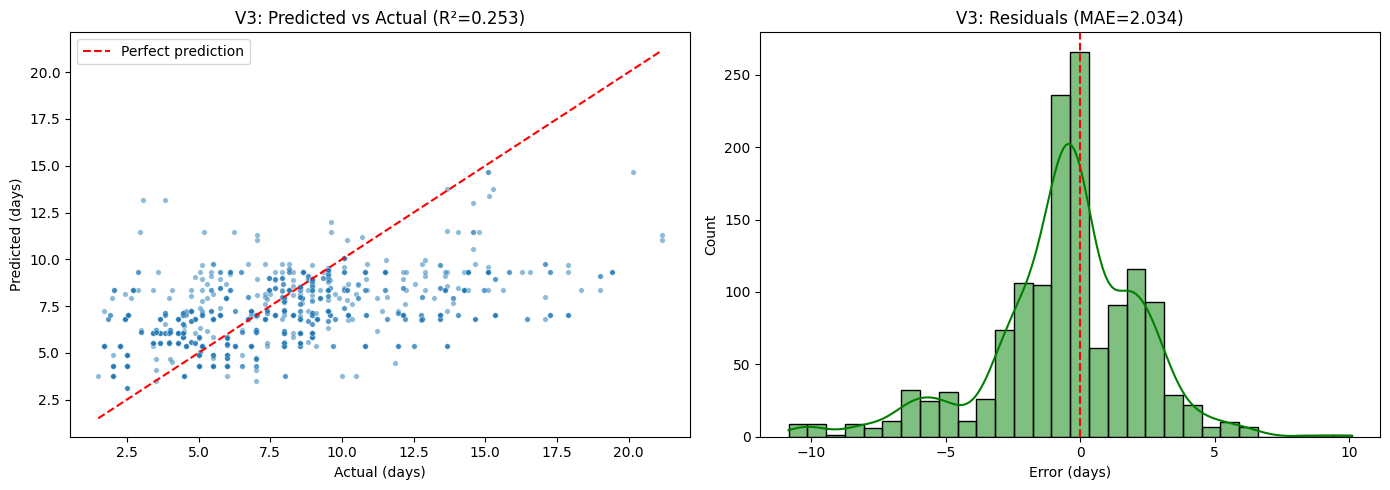


✅ Visualization saved → deadline_scatter_v3.png


In [21]:
# -------------------------------------------------------
# 1️⃣2️⃣ VISUALIZATION
# -------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax1 = axes[0]
sns.scatterplot(x=y_true, y=y_pred_final, alpha=0.5, s=15, edgecolor='w', ax=ax1)
ax1.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()], 'r--', label='Perfect prediction')
ax1.set_xlabel('Actual (days)')
ax1.set_ylabel('Predicted (days)')
ax1.set_title(f'V3: Predicted vs Actual (R²={final_r2:.3f})')
ax1.legend()

# Residuals
ax2 = axes[1]
residuals = y_pred_final - y_true
sns.histplot(residuals, bins=30, kde=True, color='green', ax=ax2)
ax2.axvline(0, color='red', linestyle='--')
ax2.set_title(f'V3: Residuals (MAE={final_mae:.3f})')
ax2.set_xlabel('Error (days)')

plt.tight_layout()
plt.savefig('deadline_scatter_v3.png', dpi=150)
plt.show()

print('\n✅ Visualization saved → deadline_scatter_v3.png')


In [22]:
# -------------------------------------------------------
# 1️⃣3️⃣ INFERENCE FUNCTION
# -------------------------------------------------------
def predict_deadline(items):
    """Predict deadline for a list of items.
    
    Each item should have: issuetype, priorityid, storypoint, project
    Compatible with V2 API for n8n workflow.
    """
    out = []
    for it in items:
        # Create base dataframe
        df_one = pd.DataFrame([it])
        
        # Add engineered features
        sp = it.get('storypoint', 0) or 0
        prio = it.get('priorityid', 3) or 3
        
        df_one['storypoint_log'] = np.log1p(sp)
        df_one['priority_score'] = 6 - min(max(prio, 1), 5)
        df_one['complexity'] = df_one['storypoint_log'] * df_one['priority_score']
        
        # Predict
        yhat = np.expm1(pipe.predict(df_one[safe_num_feats + safe_cat_feats]))[0]
        days = max(1, round(min(yhat, 180)))
        out.append({'predicted_deadline_days': int(days)})
    return out


In [23]:
# -------------------------------------------------------
# 1️⃣4️⃣ TEST INFERENCE
# -------------------------------------------------------
if __name__ == '__main__':
    dummy_items = [
        {'issuetype': 'Bug', 'priorityid': 1, 'storypoint': 5, 'project': 'TKTI'},
        {'issuetype': 'Story', 'priorityid': 2, 'storypoint': 8, 'project': 'Aurora'},
        {'issuetype': 'Task', 'priorityid': 4, 'storypoint': 13, 'project': 'UserGrid'},
    ]

    preds = predict_deadline(dummy_items)
    print('\n📋 Sample Predictions:')
    for i, res in enumerate(preds):
        item = dummy_items[i]
        print(f"   {item['project']} / {item['issuetype']} (SP:{item['storypoint']}, Prio:{item['priorityid']}) "
              f"→ {res['predicted_deadline_days']} days")



📋 Sample Predictions:
   TKTI / Bug (SP:5, Prio:1) → 9 days
   Aurora / Story (SP:8, Prio:2) → 9 days
   UserGrid / Task (SP:13, Prio:4) → 7 days
